In [1]:
import numpy as np
import time as tm
import matplotlib.pyplot as plt

In [2]:
def jacobi(A, b, x0, tol, max_iterations):
    
    n = len(b)
    x = x0.copy()
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
            # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        
        x = x_new
    return x, max_iterations


In [3]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    
    n = len(b)
    x = x0.copy()
    
    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
            # Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k
        
        x = x_new
    return x, max_iterations


In [4]:
A = np.array([[3, -0.1, -0.2],[0.1, 7, -0.3],[0.3, -0.2, 10]])
b = np.array([7.85, -19.3, 71.4])

x0 = np.zeros_like(b)
tol1 = 1e-3 #tolerance 1
tol2 = 1e-6 #tolerance 2
tol3 = 1e-9 #tolerance 3
max_iterations = 100

solution1, iterations1 = jacobi(A, b, x0, tol1, max_iterations) #Jacobi iterations w/ tol1
solution2, iterations2 = jacobi(A, b, x0, tol2, max_iterations) #Jacobi iterations w/ tol2
solution3, iterations3 = jacobi(A, b, x0, tol3, max_iterations) #Jacobi iterations w/ tol3

print(f"Jacobi Solution: {solution1, solution2, solution3}")
print(f"Iterations: {iterations1, iterations2, iterations3}")



solution4, iterations4 = gauss_seidel(A, b, x0, tol1, max_iterations) #Gauss-seidel iteration w/ tol1
solution5, iterations5 = gauss_seidel(A, b, x0, tol2, max_iterations) #Gauss-seidel iteration w/ tol2
solution6, iterations6 = gauss_seidel(A, b, x0, tol3, max_iterations) #Gauss-seidel iteration w/ tol3

print(f"\nGauss Seidel Solution: {solution4, solution5, solution6}")
print(f"Iterations: {iterations4, iterations5, iterations6}")


Jacobi Solution: (array([ 3.0000225 , -2.50000266,  6.99998104]), array([ 3. , -2.5,  7. ]), array([ 3. , -2.5,  7. ]))
Iterations: (3, 6, 8)

Gauss Seidel Solution: (array([ 3.00000035, -2.50000004,  6.99999999]), array([ 3. , -2.5,  7. ]), array([ 3. , -2.5,  7. ]))
Iterations: (3, 4, 6)


Using these methods, the tolerance 1 of 1e-3, they both run 3 iterations to converge; with a tolerance of 1e-6, Jacobi took 6 iterations while Gauss Seidel took 4 to converge; with a tolerance of 1e-9, it took Jacobi 8 iterations and Gauss Seidel 6 iterations to converge.

In [5]:
true_sol = np.linalg.solve(A, b)

Text(0.5, 1.0, 'Absolute Error vs Iterations in Jacobi Method')

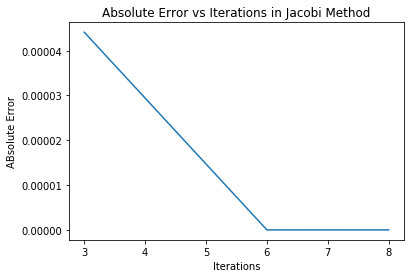

In [6]:
error1 = np.abs(true_sol[0] - solution1[0])
error2 = np.abs(true_sol[1] - solution1[1])
error3 = np.abs(true_sol[2] - solution1[2])
terror1 = error1 + error2 + error3

error1 = np.abs(true_sol[0] - solution2[0])
error2 = np.abs(true_sol[1] - solution2[1])
error3 = np.abs(true_sol[2] - solution2[2])
terror2 = error1 + error2 + error3

error1 = np.abs(true_sol[0] - solution3[0])
error2 = np.abs(true_sol[1] - solution3[1])
error3 = np.abs(true_sol[2] - solution3[2])
terror3 = error1 + error2 + error3

error = [terror1, terror2, terror3]
iterations = [3, 6, 8]

plt.plot(iterations, error)
plt.xlabel("Iterations")
plt.ylabel("ABsolute Error")
plt.title("Absolute Error vs Iterations in Jacobi Method")

Text(0.5, 1.0, 'Absolute Error vs Iterations in Gauss-Seidel Method')

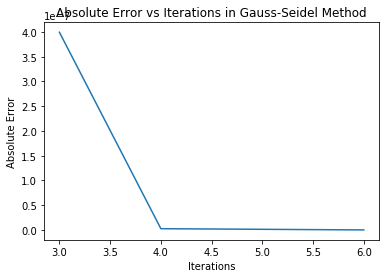

In [7]:
error1 = np.abs(true_sol[0] - solution4[0])
error2 = np.abs(true_sol[1] - solution4[1])
error3 = np.abs(true_sol[2] - solution4[2])
terror1 = error1 + error2 + error3

error1 = np.abs(true_sol[0] - solution5[0])
error2 = np.abs(true_sol[1] - solution5[1])
error3 = np.abs(true_sol[2] - solution5[2])
terror2 = error1 + error2 + error3

error1 = np.abs(true_sol[0] - solution6[0])
error2 = np.abs(true_sol[1] - solution6[1])
error3 = np.abs(true_sol[2] - solution6[2])
terror3 = error1 + error2 + error3

error = [terror1, terror2, terror3]
iterations = [3, 4, 6]

plt.plot(iterations, error)
plt.xlabel("Iterations")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Iterations in Gauss-Seidel Method")

A tighter tolerance forces the method to keep iterating until the updates between successive approximations become extremely small, so the number of iterations increases as the tolerance becomes smaller. With a loose tolerance like 1e-3, both methods stop quickly because the solution only needs to be roughly accurate, but with tighter tolerances such as 1e-6 or 1e-9, the algorithms must refine the solution much more, leading to more iterations, though Gauss–Seidel consistently reaches those tighter thresholds in fewer steps than Jacobi.